# Six-node peer-to-peer LoRa: 923 MHz campus PHY study

Start with **six identical RAK4631(H)/SX1262 peers**, three per floor, with upright external RAKARJ10 antennas and pigtails. There is no gateway: each node transmits separately while the other five receive. This gives **30 directed links**. Six is an experiment size, not an estimated coverage requirement.

Placement is seeded, with a **minimum horizontal separation on the same floor**, not equal distances between every pair. Conservative allowed regions cover corridors, the library, the ground-floor atrium and its upstairs walkway, and the upstairs public computing suite. Labs and lecture halls are excluded. Inspect the floor plans before using the coordinates on site.

**VS Code:** select `nvidia/.venv-lora/bin/python`, then Run All. The default CPU backend and static plots do not require WebGL. The optional interactive preview appears **inside the notebook**, not in a new window; see [the directory README](README.md) if only its controls appear. This notebook uses the assets inside `sionna-lora-ext/assets` and leaves notebook 0 independent.

Outputs: node coordinates, RSS and sensitivity-margin matrices, a distance scatter plot, a 3D node view, and per-floor signal maps from dense virtual receivers. These are ray-traced predictions, **not hardware RSSI measurements, packet delivery estimates, or MAC/collision simulations**.

In [1]:
from pathlib import Path
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown
import mitsuba as mi

# Restart the kernel before changing variant. CPU works without CUDA or WebGL.
mi.set_variant("llvm_ad_mono_polarized")
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, PathSolver

def find_repo_root(start=Path.cwd()):
    for parent in (start, *start.parents):
        for candidate in (parent, parent / "sionna-lora-ext"):
            if (candidate / "assets/sionna/scene_923MHz.xml").is_file():
                return candidate
    raise FileNotFoundError("Open this notebook from the nvidia or sionna-lora-ext workspace.")

REPO_ROOT = find_repo_root()
SCENE_PATH = REPO_ROOT / "assets/sionna/scene_923MHz.xml"
print("Sionna RT", importlib.metadata.version("sionna-rt"), "|", mi.variant())
print(SCENE_PATH)

Sionna RT 2.1.0 | llvm_ad_mono_polarized
/home/ubuntu/Desktop/sk/nvidia/sionna-lora-ext/assets/sionna/scene_923MHz.xml


## Hardware assumptions and received-power convention

Use the [RAK4631 high-band module](https://docs.rakwireless.com/product-categories/wisblock/rak4631/datasheet/) and the [RAKARJ10 902–930 MHz monopole](https://docs.rakwireless.com/product-categories/accessories/rakarj10/datasheet/) corresponding to the selected [external antenna product](https://store.rakwireless.com/products/lora-antenna). Its published peak gains at 922 and 924 MHz give an interpolated **1.96 dBi at 923 MHz**. A vertical half-wave dipole pattern scaled to that peak is an initial directional surrogate, not the measured installed monopole pattern. Ground plane, enclosure, orientation, people and cable routing need calibration.

The working power is **+14 dBm at the module's conducted output**, with provisional **1 dB pigtail/connector loss at each end**. Extra module RX-path loss is unknown and starts at 0 dB explicitly. Predicted RSS below is at the modeled chip input after those losses. Do not count antenna efficiency again when using gain.

SF7 **−124 dBm** and SF12 **−137 dBm** are typical boosted-receiver chip sensitivity anchors at 125 kHz, 1% PER, CR 4/5, 64-byte packet, 8-symbol preamble, explicit header and CRC: [Semtech December 2024 datasheet](../../../ref/semtech-sx1261-sx1262-datasheet-2024.pdf), test conditions page 16 and Table 3-8 page 20. Tests include 915 MHz; applying them at 923 MHz is a nearby-band assumption. RF-switch insertion loss is excluded. These are not measured board sensitivities; no intermediate-SF values are invented.

The propagation channel does not change with SF. SF only changes the sensitivity screen here. A 10 dB reserve is an editable design target, not a probability of delivery. Power is averaged over the 125 kHz channel using coherent multipath at each sampled frequency and an approximately flat chirp energy spectrum. No noise or interference is added to the signal-power estimate.

In [ ]:
SEED = 42
N_NODES = 6
MIN_SPACING_M = 5.0             # Horizontal, within each floor only
ANTENNA_HEIGHT_M = 1.3          # Above physical finished floor
CLEARANCE_M = 0.35
FREQUENCY_HZ = 923e6
BANDWIDTH_HZ = 125e3
TX_CONDUCTED_DBM = 14.0
ANTENNA_PEAK_DBI = 1.96
TX_PIGTAIL_LOSS_DB = 1.0
RX_PIGTAIL_LOSS_DB = 1.0
EXTRA_RX_BOARD_LOSS_DB = 0.0    # Unknown; replace with measured board loss
SENSITIVITY_DBM = {7: -124.0, 12: -137.0}
FADE_RESERVE_DB = 10.0

# Pilot computation budget; increase and compare before trusting weak links.
SAMPLES_PER_SRC = 1_000_000
MAX_DEPTH = 8
RECIPROCITY_TOL_DB = 3.0       # Diagnostic tolerance, not a delivery guarantee
ENABLE_DIFFRACTION = True
MAP_TX_INDEX = 0                # Change to inspect a different peer
MAP_STEP_M = 2.0                # Decrease to 1.0 / 0.5 for denser floor slices
MAP_BATCH_SIZE = 128
RUN_MAPS = True
OPEN_INTERACTIVE_PREVIEW = True

# RF sheets are not always the physical walking surface: the F2 slab is
# represented at its mid-plane, 0.455 m below the finished floor.
FLOORS = {
    "F1": {"surface_z": -1.4370243549, "support_z": -1.4370243549},
    "F2": {"surface_z": 2.5087316036, "support_z": 2.0540938},
}
# Bounds: xmin, xmax, ymin, ymax. Each region gets one node initially.
# Small audited subsets, not a semantic segmentation of every public space.
REGIONS = [
    {"name": "South corridor", "floor": "F1", "bounds": (-57, -28, 13, 15.5), "count": 1},
    {"name": "Library", "floor": "F1", "bounds": (-19, -3, 35, 44), "count": 1},
    {"name": "Atrium ground floor", "floor": "F1", "bounds": (-34, -24, 39, 44), "count": 1},
    {"name": "Public computing suite", "floor": "F2", "bounds": (-58, -38, 25.5, 28.5), "count": 1},
    {"name": "Atrium east walkway", "floor": "F2", "bounds": (-16, -14, 25, 43), "count": 1},
    {"name": "South junction", "floor": "F2", "bounds": (-32, -25, 14, 20), "count": 1},
]
assert N_NODES == sum(r["count"] for r in REGIONS), "Set N_NODES and region counts together."
assert N_NODES >= 2 and all(isinstance(r["count"], int) and r["count"] >= 0 for r in REGIONS)
assert np.isfinite([MIN_SPACING_M, ANTENNA_HEIGHT_M, CLEARANCE_M, MAP_STEP_M]).all()
assert MIN_SPACING_M > 0 and ANTENNA_HEIGHT_M > CLEARANCE_M > 0 and MAP_STEP_M > 0
assert 0 <= MAP_TX_INDEX < N_NODES and MAP_BATCH_SIZE > 0
assert all(r["floor"] in FLOORS and np.isfinite(r["bounds"]).all()
           and r["bounds"][0] < r["bounds"][1] and r["bounds"][2] < r["bounds"][3] for r in REGIONS)

scene = load_scene(str(SCENE_PATH), merge_shapes=True)
scene.frequency = FREQUENCY_HZ
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="hw_dipole", polarization="V")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="hw_dipole", polarization="V")
# The native pattern already has a 10*log10(1.643) dBi peak. Apply only the difference.
PATTERN_CORRECTION_DB = ANTENNA_PEAK_DBI - 10 * np.log10(1.643)
FREQ_OFFSETS = np.linspace(-BANDWIDTH_HZ / 2, BANDWIDTH_HZ / 2, 17)
solver = PathSolver(deterministic=True)

## Place peers in the allowed regions

A downward ray must reach the correct floor sheet, rather than a table, stair or the floor below. Eight short horizontal rays at three heights check clearance. This conservatively rejects positions above furniture and most near-wall locations. It is not a volumetric collision certificate: re-audit the regions if the geometry changes. In particular, the upstairs atrium centre is a **void**, not a placement area.

For more/fewer peers, edit `N_NODES` and the region `count` entries together. A failed spacing constraint raises an error rather than silently moving nodes into excluded rooms or reducing the spacing.

In [3]:
def geometry_clear(points, floor):
    points = np.asarray(points, dtype=float).reshape(-1, 3)
    if not len(points):
        return np.zeros(0, dtype=bool)
    origins = mi.Point3f(points.T)
    hit = scene.mi_scene.ray_intersect(mi.Ray3f(origins, mi.Vector3f(0, 0, -1)))
    valid = np.asarray(hit.is_valid()) & np.isclose(np.asarray(hit.p.z), FLOORS[floor]["support_z"], atol=0.03)
    # ponytail: sparse rays can miss thin/concave solids; use mesh-distance or
    # volume occupancy checks if placement needs a certified clearance envelope.
    for height in (0.15, ANTENNA_HEIGHT_M / 2, ANTENNA_HEIGHT_M):
        origins_at_height = points.copy()
        origins_at_height[:, 2] = FLOORS[floor]["surface_z"] + height
        for angle in np.arange(8) * np.pi / 4:
            ray = mi.Ray3f(mi.Point3f(origins_at_height.T), mi.Vector3f(float(np.cos(angle)), float(np.sin(angle)), 0))
            ray.maxt = CLEARANCE_M
            valid &= ~np.asarray(scene.mi_scene.ray_test(ray))
    return valid

def sample_nodes(seed, min_spacing=MIN_SPACING_M):
    rng = np.random.default_rng(seed)
    nodes = []
    for region in REGIONS:
        xmin, xmax, ymin, ymax = region["bounds"]
        for _ in range(region["count"]):
            for attempt in range(1000):
                p = np.array([rng.uniform(xmin, xmax), rng.uniform(ymin, ymax),
                              FLOORS[region["floor"]]["surface_z"] + ANTENNA_HEIGHT_M])
                separated = all(n["floor"] != region["floor"] or
                                np.linalg.norm(p[:2] - n["position"][:2]) >= min_spacing for n in nodes)
                if separated and geometry_clear([p], region["floor"])[0]:
                    nodes.append({"name": f"N{len(nodes) + 1}", "floor": region["floor"],
                                  "region": region["name"], "position": p})
                    break
            else:
                raise ValueError(f"Cannot place {region['name']} after 1000 attempts; revise count/spacing/region.")
    return nodes

nodes = sample_nodes(SEED)
positions = np.array([n["position"] for n in nodes])
labels = [n["name"] for n in nodes]
node_floors = np.array([n["floor"] for n in nodes])
distance_m = np.linalg.norm(positions[:, None, :] - positions[None, :, :], axis=-1)
assert len(nodes) == N_NODES
assert np.array_equal(positions, np.array([n["position"] for n in sample_nodes(SEED)]))
for i, node in enumerate(nodes):
    assert geometry_clear([node["position"]], node["floor"])[0]
    for j in range(i):
        if node["floor"] == nodes[j]["floor"]:
            assert np.linalg.norm(positions[i, :2] - positions[j, :2]) >= MIN_SPACING_M
# A known atrium-void location must never pass the F2 floor-support test.
assert not geometry_clear([[-29, 40, FLOORS["F2"]["surface_z"] + ANTENNA_HEIGHT_M]], "F2")[0]
rows = ["| Node | Floor | Public region | x (m) | y (m) | z (m) |", "|---|---|---|---:|---:|---:|"]
for n in nodes:
    x, y, z = n["position"]
    rows.append(f"| {n['name']} | {n['floor']} | {n['region']} | {x:.2f} | {y:.2f} | {z:.2f} |")
display(Markdown("\n".join(rows)))
print("Placement self-check passed: reproducible count, spacing, clearance and void rejection.")

| Node | Floor | Public region | x (m) | y (m) | z (m) |
|---|---|---|---:|---:|---:|
| N1 | F1 | South corridor | -34.56 | 14.10 | -0.14 |
| N2 | F1 | Library | -5.26 | 41.28 | -0.14 |
| N3 | F1 | Atrium ground floor | -33.06 | 43.88 | -0.14 |
| N4 | F2 | Public computing suite | -42.78 | 27.86 | 3.81 |
| N5 | F2 | Atrium east walkway | -15.74 | 33.11 | 3.81 |
| N6 | F2 | South junction | -28.90 | 15.36 | 3.81 |

Placement self-check passed: reproducible count, spacing, clearance and void rejection.


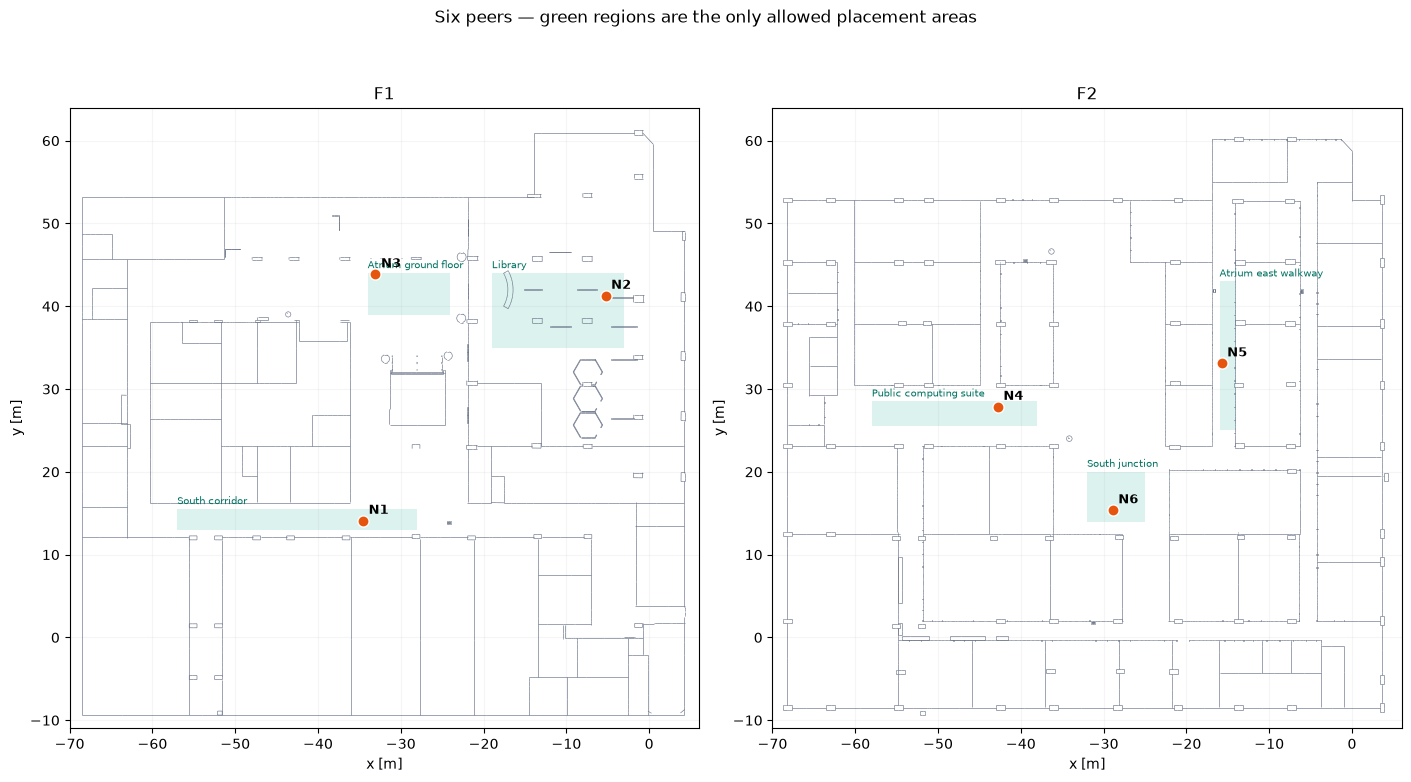

In [4]:
# Slice the existing meshes, rather than drawing an invented floor plan.
def floor_segments(z):
    segments = []
    for mesh in scene.mi_scene.shapes():
        params = mi.traverse(mesh)
        vertices = np.asarray(params["vertex_positions"]).reshape(-1, 3)
        triangles = vertices[np.asarray(params["faces"]).reshape(-1, 3)]
        triangles = triangles[(triangles[:, :, 2].min(1) < z) & (triangles[:, :, 2].max(1) > z)]
        intersections = np.full((len(triangles), 3, 2), np.nan)
        for e, (a, b) in enumerate(((0, 1), (1, 2), (2, 0))):
            p, q = triangles[:, a], triangles[:, b]
            crosses = (p[:, 2] < z) != (q[:, 2] < z)
            t = (z - p[crosses, 2]) / (q[crosses, 2] - p[crosses, 2])
            intersections[crosses, e] = (p[crosses] + t[:, None] * (q[crosses] - p[crosses]))[:, :2]
        # Each straddling triangle has exactly two crossing edges.
        segments.extend(intersections[np.isfinite(intersections).all(-1)].reshape(-1, 2, 2))
    return np.asarray(segments)

floor_lines = {f: floor_segments(info["surface_z"] + ANTENNA_HEIGHT_M) for f, info in FLOORS.items()}

def draw_floor(ax, floor, show_regions=True):
    ax.add_collection(LineCollection(floor_lines[floor], colors="#667085", linewidths=0.45, zorder=2))
    if show_regions:
        for r in REGIONS:
            if r["floor"] == floor:
                x0, x1, y0, y1 = r["bounds"]
                ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, facecolor="#00a68a", alpha=0.14))
                ax.text(x0, y1+0.6, r["name"], fontsize=7, color="#007362")
    for n in nodes:
        if n["floor"] == floor:
            x, y = n["position"][:2]
            ax.scatter(x, y, s=65, color="#e6550d", edgecolor="white", zorder=5)
            ax.annotate(n["name"], (x, y), xytext=(4, 5), textcoords="offset points", fontsize=9, weight="bold", zorder=6)
    ax.set(xlim=(-70, 6), ylim=(-11, 64), aspect="equal", xlabel="x [m]", ylabel="y [m]", title=floor)
    ax.grid(alpha=0.12)

fig, axes = plt.subplots(1, 2, figsize=(14, 8), layout="constrained")
for ax, floor in zip(axes, FLOORS):
    draw_floor(ax, floor)
fig.suptitle("Six peers — green regions are the only allowed placement areas")
plt.show()

## Trace one transmitter to the other receivers

Each link uses SISO vertical polarization, line of sight, specular reflections, slab/wall transmission, and optionally diffraction. Diffuse scattering is disabled. The scene's material assumptions, geometry and finite path search limit accuracy, especially through floors. The default uses one million rays per source and depth 8, but this does **not** establish convergence. Increase ray samples/depth and compare seeds before interpreting link margins. Identical passive links should be reciprocal: large forward/reverse differences are numerical/model diagnostics, not evidence that these identical radios inherently form one-way links.

`Paths.cfr(normalize=False)` preserves absolute channel loss. We average **linear** power, not dB values, over frequency. The same solver and receive antenna are used for links and virtual receiver maps. A path with zero computed gain remains `−inf`, meaning **no path found**, not a fabricated RSS floor; missing paths need further solver checks before being called a physical outage.

In [5]:
def gain_to_rss(gain):
    gain = np.asarray(gain, dtype=float)
    if np.any(~np.isfinite(gain)) or np.any(gain < 0):
        raise ValueError("Channel power gain must be finite and nonnegative.")
    with np.errstate(divide="ignore"):
        return (TX_CONDUCTED_DBM + 10 * np.log10(gain) + 2 * PATTERN_CORRECTION_DB
                - TX_PIGTAIL_LOSS_DB - RX_PIGTAIL_LOSS_DB - EXTRA_RX_BOARD_LOSS_DB)

def trace_rss(rt_scene, tx_position, rx_positions, *, seed=SEED, los_only=False):
    rx_positions = np.asarray(rx_positions, dtype=float).reshape(-1, 3)
    if not len(rx_positions) or not np.isfinite(rx_positions).all() or not np.isfinite(tx_position).all():
        raise ValueError("Provide finite transmitter and nonempty receiver coordinates.")
    if np.any(np.linalg.norm(rx_positions - tx_position, axis=1) < 0.5):
        raise ValueError("Exclude self links and receivers within 0.5 m of the transmitter.")
    if rt_scene.transmitters or rt_scene.receivers:
        raise ValueError("Use a scene without existing radio devices; rerun scene setup after preview.")
    try:
        rt_scene.add(Transmitter(name="probe_tx", position=tx_position, power_dbm=TX_CONDUCTED_DBM))
        for j, p in enumerate(rx_positions):
            rt_scene.add(Receiver(name=f"probe_rx_{j}", position=p))
        paths = solver(scene=rt_scene, max_depth=0 if los_only else MAX_DEPTH,
                       samples_per_src=1 if los_only else SAMPLES_PER_SRC,
                       los=True, specular_reflection=not los_only, refraction=not los_only,
                       diffuse_reflection=False, diffraction=ENABLE_DIFFRACTION and not los_only,
                       seed=seed, synthetic_array=True)
        h = paths.cfr(frequencies=mi.Float(FREQ_OFFSETS), normalize=False, out_type="numpy")
        assert h.shape == (len(rx_positions), 1, 1, 1, 1, len(FREQ_OFFSETS))
        power = np.abs(h[:, 0, 0, 0, 0, :])**2
        gain = np.trapezoid(power, FREQ_OFFSETS, axis=-1) / BANDWIDTH_HZ
        return gain_to_rss(gain)
    finally:
        for name in list(rt_scene.transmitters) + list(rt_scene.receivers):
            rt_scene.remove(name)

# Runnable independent physics check: absolute gain, power conversion, and feed losses.
free_space = load_scene()
free_space.frequency = FREQUENCY_HZ
free_space.tx_array, free_space.rx_array = scene.tx_array, scene.rx_array
check_rss = trace_rss(free_space, np.array([0, 0, 0]), [[10, 0, 0], [20, 0, 0]], los_only=True)
wavelength = 299_792_458 / FREQUENCY_HZ
friis_rss = (TX_CONDUCTED_DBM + 2 * ANTENNA_PEAK_DBI - TX_PIGTAIL_LOSS_DB - RX_PIGTAIL_LOSS_DB
             - EXTRA_RX_BOARD_LOSS_DB - 20*np.log10(4*np.pi*np.array([10, 20])/wavelength))
np.testing.assert_allclose(check_rss, friis_rss, atol=0.05)
np.testing.assert_allclose(check_rss[0] - check_rss[1], 20*np.log10(2), atol=0.02)
assert np.isneginf(gain_to_rss([0]))[0]
assert not free_space.transmitters and not free_space.receivers
print("Physics self-check passed: Friis power at 10/20 m, 6.02 dB distance loss, zero gain, device cleanup.")

Physics self-check passed: Friis power at 10/20 m, 6.02 dB distance loss, zero gain, device cleanup.


In [6]:
# Row = transmitting node, column = receiving node. Diagonal has no self links.
rss_dbm = np.full((N_NODES, N_NODES), np.nan)
for tx in range(N_NODES):
    others = np.arange(N_NODES) != tx
    rss_dbm[tx, others] = trace_rss(scene, positions[tx], positions[others])
    print(f"{labels[tx]} -> {others.sum()} peers complete")
assert np.isnan(np.diag(rss_dbm)).all()
assert np.count_nonzero(~np.isnan(rss_dbm)) == N_NODES * (N_NODES - 1)
margin_db = {sf: rss_dbm - sensitivity for sf, sensitivity in SENSITIVITY_DBM.items()}
reciprocal = np.isfinite(rss_dbm) & np.isfinite(rss_dbm.T)
if reciprocal.any():
    discrepancy = np.max(np.abs(rss_dbm[reciprocal] - rss_dbm.T[reciprocal]))
    print(f"Largest forward/reverse difference: {discrepancy:.2f} dB (sampling/convergence diagnostic).")
print("No-path directed links:", np.isneginf(rss_dbm).sum())
reciprocity_error_db = np.full_like(rss_dbm, np.nan)
reciprocity_error_db[reciprocal] = np.abs(rss_dbm[reciprocal] - rss_dbm.T[reciprocal])
unresolved_pairs = np.triu((reciprocity_error_db > RECIPROCITY_TOL_DB) |
                          np.isneginf(rss_dbm) | np.isneginf(rss_dbm.T), 1)
if unresolved_pairs.any():
    display(Markdown(f"**Unconverged exploratory results:** {unresolved_pairs.sum()} physical pairs "
                     f"have >{RECIPROCITY_TOL_DB:g} dB forward/reverse discrepancy or a missing path. "
                     "Do not treat the margins below as established coverage. "
                     "Increase samples/depth and compare seeds; investigate geometry/materials if differences persist."))
    print("Pairs requiring investigation:", ", ".join(f"{labels[i]}↔{labels[j]}" for i, j in zip(*np.where(unresolved_pairs))))
else:
    print("Reciprocity screen passed; independent sample-budget/seed convergence and calibration are still required.")

N1 -> 5 peers complete
N2 -> 5 peers complete
N3 -> 5 peers complete
N4 -> 5 peers complete
N5 -> 5 peers complete
N6 -> 5 peers complete
Largest forward/reverse difference: 34.00 dB (sampling/convergence diagnostic).
No-path directed links: 0


**Unconverged exploratory results:** 13 physical pairs have >3 dB forward/reverse discrepancy or a missing path. Do not treat the margins below as established coverage. Increase samples/depth and compare seeds; investigate geometry/materials if differences persist.

Pairs requiring investigation: N1↔N2, N1↔N3, N1↔N4, N1↔N5, N1↔N6, N2↔N3, N2↔N6, N3↔N4, N3↔N5, N3↔N6, N4↔N5, N4↔N6, N5↔N6


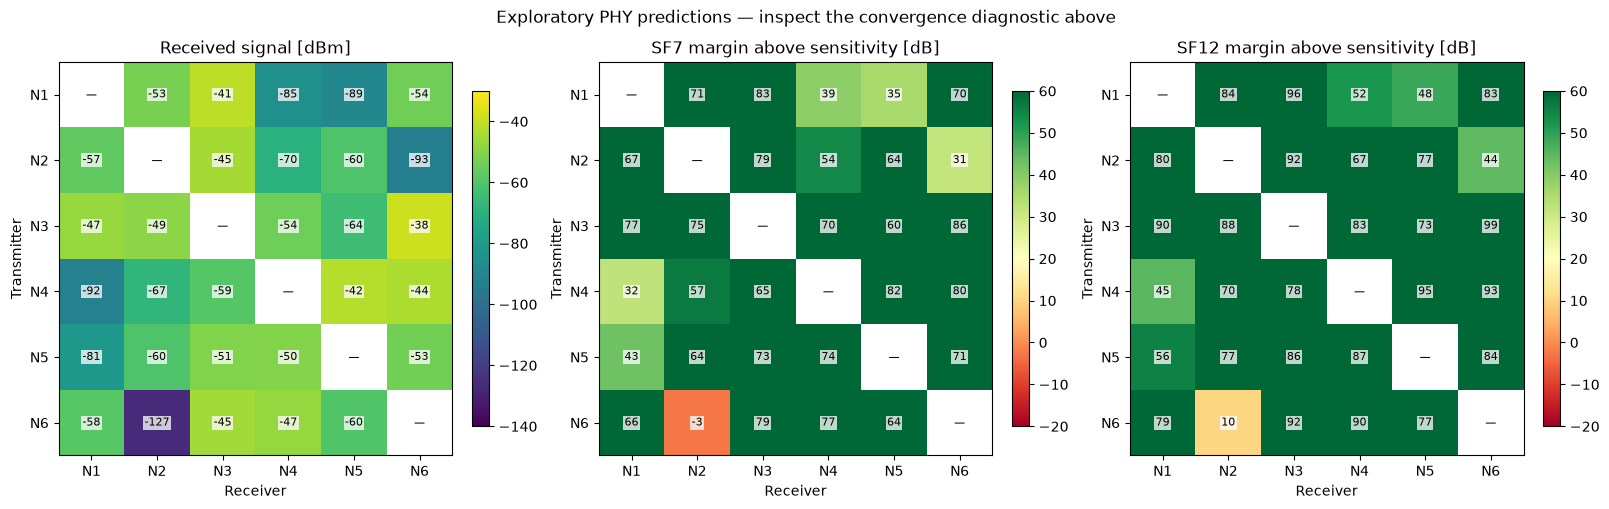

Raw model sensitivity screen; counts are not convergence-qualified coverage:
SF7: 29/30 directed links, 14/15 bidirectional pairs meet 10 dB reserve.
SF12: 30/30 directed links, 15/15 bidirectional pairs meet 10 dB reserve.
Pigtail sensitivity, changing the assumed loss at BOTH ends:
  0 dB/end: SF7 links meeting reserve = 29
  1 dB/end: SF7 links meeting reserve = 29
  2 dB/end: SF7 links meeting reserve = 29


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), layout="constrained")
matrices = [(rss_dbm, "Received signal [dBm]", "viridis", -140, -30),
            (margin_db[7], "SF7 margin above sensitivity [dB]", "RdYlGn", -20, 60),
            (margin_db[12], "SF12 margin above sensitivity [dB]", "RdYlGn", -20, 60)]
for ax, (values, title, cmap, low, high) in zip(axes, matrices):
    im = ax.imshow(np.ma.masked_invalid(values), cmap=cmap, vmin=low, vmax=high)
    for i in range(N_NODES):
        for j in range(N_NODES):
            label = "—" if i == j else ("no path" if np.isneginf(values[i, j]) else f"{values[i, j]:.0f}")
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=1))
    ax.set(xticks=range(N_NODES), yticks=range(N_NODES), xticklabels=labels, yticklabels=labels,
           xlabel="Receiver", ylabel="Transmitter", title=title)
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle("Exploratory PHY predictions — inspect the convergence diagnostic above")
plt.show()

print("Raw model sensitivity screen; counts are not convergence-qualified coverage:")
for sf, values in margin_db.items():
    directed_pass = np.count_nonzero(values >= FADE_RESERVE_DB)
    both_directions = (values >= FADE_RESERVE_DB) & (values.T >= FADE_RESERVE_DB)
    pairs_pass = np.count_nonzero(np.triu(both_directions, 1))
    print(f"SF{sf}: {directed_pass}/{N_NODES*(N_NODES-1)} directed links, "
          f"{pairs_pass}/{N_NODES*(N_NODES-1)//2} bidirectional pairs meet {FADE_RESERVE_DB:g} dB reserve.")
print("Pigtail sensitivity, changing the assumed loss at BOTH ends:")
for cable_loss in (0.0, 1.0, 2.0):
    adjusted = rss_dbm + TX_PIGTAIL_LOSS_DB + RX_PIGTAIL_LOSS_DB - 2*cable_loss
    print(f"  {cable_loss:g} dB/end: SF7 links meeting reserve = "
          f"{np.count_nonzero(adjusted - SENSITIVITY_DBM[7] >= FADE_RESERVE_DB)}")

## Distance and 3D context

The scatter retains individual directed links; reciprocal observations are not independent samples. Six nodes provide only 15 physical pairs, so a smooth fitted propagation curve would imply more evidence than this pilot provides. Compare same-floor and cross-floor links, then repeat seeds or add real measurements before fitting a distance model.

The 3D figure shows floor slices and the links from the selected transmitter. It is a height-aware overview, not a sampled 3D radio volume. Green edges meet the SF7 reserve in that direction; dashed red edges do not.

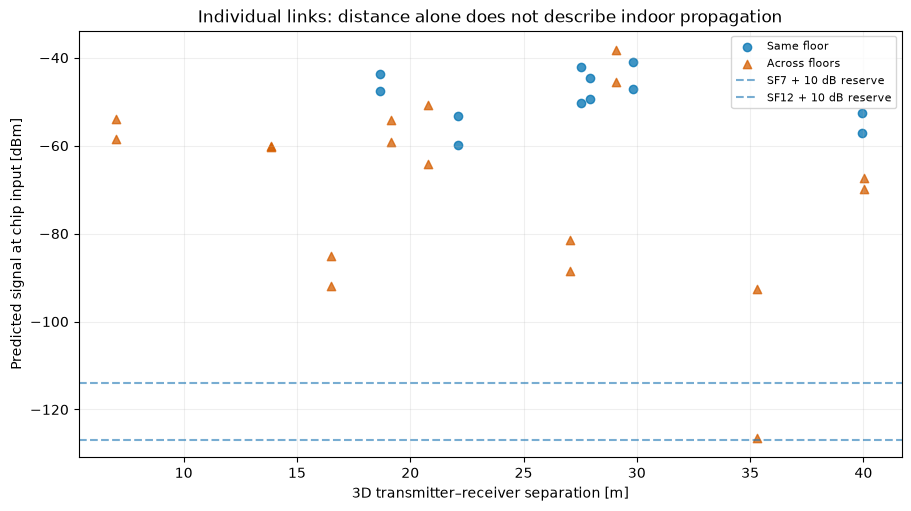

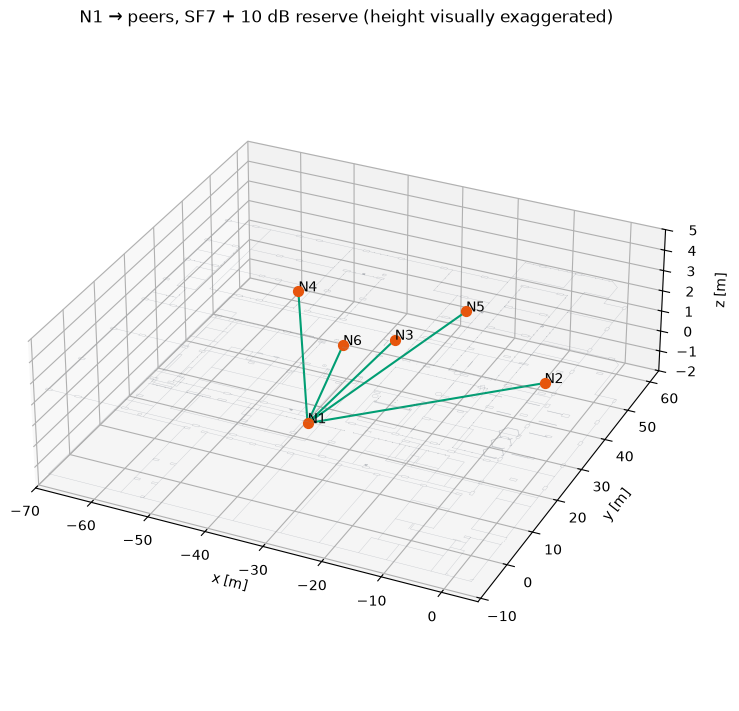

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
same_floor = node_floors[:, None] == node_floors[None, :]
for same, marker, color, label in [(True, "o", "#0072b2", "Same floor"), (False, "^", "#d55e00", "Across floors")]:
    mask = np.isfinite(rss_dbm) & (same_floor == same)
    ax.scatter(distance_m[mask], rss_dbm[mask], marker=marker, c=color, label=label, alpha=0.75)
for sf, threshold in SENSITIVITY_DBM.items():
    ax.axhline(threshold + FADE_RESERVE_DB, ls="--", alpha=0.6, label=f"SF{sf} + {FADE_RESERVE_DB:g} dB reserve")
ax.set(xlabel="3D transmitter–receiver separation [m]", ylabel="Predicted signal at chip input [dBm]",
       title="Individual links: distance alone does not describe indoor propagation")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.show()

fig = plt.figure(figsize=(12, 7), layout="constrained")
ax = fig.add_subplot(111, projection="3d")
from mpl_toolkits.mplot3d.art3d import Line3DCollection
for floor, lines in floor_lines.items():
    z = FLOORS[floor]["surface_z"]
    xyz = np.concatenate([lines, np.full((*lines.shape[:2], 1), z)], axis=-1)
    ax.add_collection3d(Line3DCollection(xyz, colors="#8c929c", linewidths=0.3, alpha=0.4))
for i, n in enumerate(nodes):
    ax.scatter(*n["position"], c="#e6550d", s=50)
    ax.text(*n["position"], n["name"])
    if i != MAP_TX_INDEX:
        segment = positions[[MAP_TX_INDEX, i]]
        passed = margin_db[7][MAP_TX_INDEX, i] >= FADE_RESERVE_DB
        ax.plot(*segment.T, color="#009e73" if passed else "#d55e00", ls="-" if passed else "--")
ax.set(xlim=(-70, 6), ylim=(-11, 64), zlim=(-2, 5), xlabel="x [m]", ylabel="y [m]", zlabel="z [m]",
       title=f"{labels[MAP_TX_INDEX]} → peers, SF7 + {FADE_RESERVE_DB:g} dB reserve (height visually exaggerated)")
ax.set_box_aspect((1, 1, 0.35))
ax.view_init(elev=30, azim=-65)
plt.show()

## Floor-slice radio environment maps

These maps trace **additional virtual receivers**, not additional deployed nodes. Each uses the same height and antenna model as the peers. Only the allowed public regions are sampled. Grey building outlines provide context; white is unsampled or rejected geometry, and a black × marks a receiver where no path was found. A 0.5 m exclusion around the transmitter avoids self/near-coincident links.

Change `MAP_TX_INDEX` and rerun the map cell for another source, or reduce `MAP_STEP_M` for a finer spatial gradient. Colors show the actual sampled grid cells; they are not smoothed through walls. The default 2 m grid misses sub-wavelength fading (wavelength ≈ 0.325 m). A smooth large-scale field needs **local averaging in linear power over densely sampled locations within each walkable region**, then conversion to dBm. Interpolation of six peer measurements cannot establish a trustworthy campus-wide map.

F1 South corridor: 30 virtual receivers
F1 Library: 30 virtual receivers
F1 Atrium ground floor: 15 virtual receivers
F2 Public computing suite: 20 virtual receivers
F2 Atrium east walkway: 9 virtual receivers
F2 South junction: 8 virtual receivers


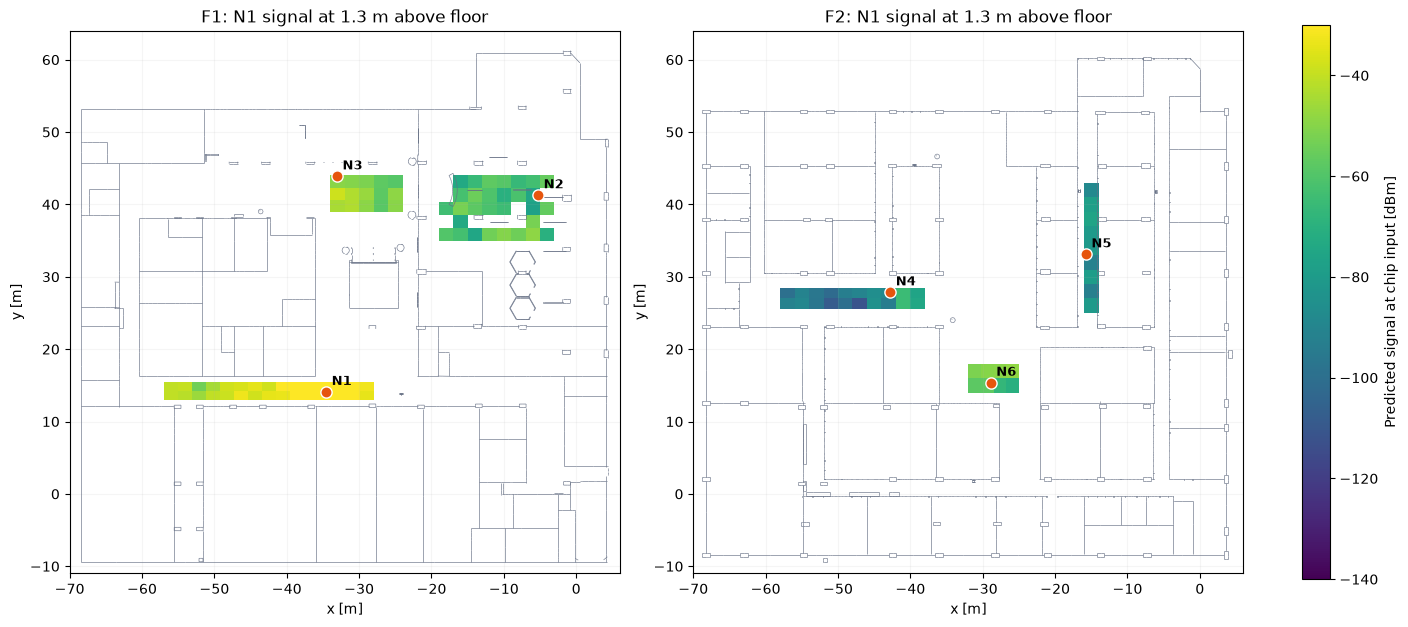

In [9]:
map_results = []
if RUN_MAPS:
    for region in REGIONS:
        x0, x1, y0, y1 = region["bounds"]
        nx, ny = max(1, int(np.ceil((x1-x0)/MAP_STEP_M))), max(1, int(np.ceil((y1-y0)/MAP_STEP_M)))
        xedges, yedges = np.linspace(x0, x1, nx+1), np.linspace(y0, y1, ny+1)
        xx, yy = np.meshgrid((xedges[:-1]+xedges[1:])/2, (yedges[:-1]+yedges[1:])/2)
        points = np.column_stack([xx.ravel(), yy.ravel(),
                                  np.full(xx.size, FLOORS[region["floor"]]["surface_z"] + ANTENNA_HEIGHT_M)])
        valid = geometry_clear(points, region["floor"])
        valid &= np.linalg.norm(points - positions[MAP_TX_INDEX], axis=1) >= 0.5
        values = np.full(len(points), np.nan)
        indices = np.flatnonzero(valid)
        for start in range(0, len(indices), MAP_BATCH_SIZE):
            batch = indices[start:start+MAP_BATCH_SIZE]
            values[batch] = trace_rss(scene, positions[MAP_TX_INDEX], points[batch])
        map_results.append({"region": region, "xedges": xedges, "yedges": yedges,
                            "points": points, "rss": values.reshape(xx.shape)})
        print(f"{region['floor']} {region['name']}: {valid.sum()} virtual receivers")

    fig, axes = plt.subplots(1, 2, figsize=(14, 8), layout="constrained")
    for ax, floor in zip(axes, FLOORS):
        for result in map_results:
            if result["region"]["floor"] == floor:
                values = result["rss"]
                im = ax.pcolormesh(result["xedges"], result["yedges"], np.ma.masked_invalid(values),
                                   cmap="viridis", vmin=-140, vmax=-30, shading="flat", zorder=1)
                no_path = np.isneginf(values.ravel())
                ax.scatter(*result["points"][no_path, :2].T, marker="x", c="black", s=12, zorder=4)
        draw_floor(ax, floor, show_regions=False)
        ax.set_title(f"{floor}: {labels[MAP_TX_INDEX]} signal at {ANTENNA_HEIGHT_M:g} m above floor")
    fig.colorbar(im, ax=axes, label="Predicted signal at chip input [dBm]", shrink=0.7)
    plt.show()
else:
    print("Set RUN_MAPS = True to trace virtual receiver grids.")

## Optional notebook 3D viewport

The static figures above remain the primary outputs in VS Code. If enabled below, Sionna opens an embedded interactive widget. It needs working WebGL; no extra desktop window is expected. The preview shows every peer with a transmitter marker purely to display locations, not to simulate simultaneous transmissions. To resume solving afterwards, rerun the scene-setup cell (or remove the preview devices).

In [10]:
if OPEN_INTERACTIVE_PREVIEW:
    for name in list(scene.transmitters) + list(scene.receivers):
        scene.remove(name)
    for node in nodes:
        scene.add(Transmitter(name=node["name"], position=node["position"], power_dbm=TX_CONDUCTED_DBM))
    scene.preview(clip_at=4.8)

## What this experiment can tell you

- Compare link budgets and weak locations for this geometry, antenna assumption and node seed. A long nominal LoRa range does not remove wall/floor losses, polarization nulls or near-far effects.
- Sensitivity margin is a PHY screening metric. Link reserve and graph edges are not confirmed packet delivery, connectivity under traffic, or a node-count recommendation.
- To investigate collisions, use these directed gains as inputs to a timed interference/LoRa PHY simulation with packet arrivals, airtime, SF/BW, capture behavior and noise. A sequential sweep contains no collisions. SISO is intentional; an antenna array/MIMO study would be a separate configuration and is not a feature of these single-radio peers.
- Congestion in the library/atrium matters here only through modeled geometry and obstruction. This scene does not simulate moving people, varying occupancy or their traffic.
- Next validate on site: record known TX power, antenna installation, cable loss, SF/BW, receiver mode and RSSI calibration at these positions. Check forward/reverse convergence, compare 0/1/2 dB feed assumptions, and increase solver samples/depth before making coverage claims. Many 923 MHz material parameters in `assets/sionna/material_manifest.json` are marked provisional and extrapolated below their documented frequency range. They are not a calibrated building survey.

The two floor slices are usually easier to interpret than a full 3D scalar field. Add multiple height slices only when the deployment actually uses those heights; avoid presenting a smoothly interpolated volume as measured evidence.